In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
data_path = "/content/drive/MyDrive/MY_data"

In [ ]:
# ===== IMPORTS =====
import os
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader

from PIL import Image

In [ ]:
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)


cuda


In [ ]:
# ===== PATHS =====
train_path = r"/content/drive/MyDrive/MY_data/train"
test_path  = r"/content/drive/MyDrive/MY_data/test"
pred_path  = r"/content/drive/MyDrive/MY_data/predict"


In [ ]:
# ===== DATA INFO =====
classes = sorted(os.listdir(train_path))
print("Classes:", classes)
print("Number of classes:", len(classes))

def count_images(path):
    total = 0
    for c in os.listdir(path):
        total += len(os.listdir(os.path.join(path, c)))
    return total

print("Train images:", count_images(train_path))
print("Test images:", count_images(test_path))

Classes: ['Apple', 'Banana', 'avocado', 'cherry', 'kiwi', 'mango', 'orange', 'pinenapple', 'strawberries', 'watermelon']
Number of classes: 10
Train images: 2301
Test images: 1025


In [ ]:
# ===== TRANSFORMS =====
train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ===== DATASETS =====
train_data = datasets.ImageFolder(train_path, transform=train_transform)
test_data  = datasets.ImageFolder(test_path, transform=test_transform)

# ===== DATALOADERS =====
train_loader = DataLoader(train_data, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_data, batch_size=32, shuffle=False)

In [ ]:
# ===== MODEL =====

model = models.resnet18(pretrained=True)

model.fc = nn.Linear(model.fc.in_features, len(classes))

model = model.to(device)

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 139MB/s]


In [ ]:

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
# ===== TRAINING =====
for epoch in range(50):
    model.train()
    total_loss = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss:.4f}")

Epoch 1, Loss: 53.2104
Epoch 2, Loss: 13.9846
Epoch 3, Loss: 7.3918
Epoch 4, Loss: 4.6141
Epoch 5, Loss: 3.9071
Epoch 6, Loss: 2.4446
Epoch 7, Loss: 1.8137
Epoch 8, Loss: 1.7239
Epoch 9, Loss: 2.5283
Epoch 10, Loss: 2.3987
Epoch 11, Loss: 1.4857
Epoch 12, Loss: 2.3414
Epoch 13, Loss: 1.6522
Epoch 14, Loss: 0.9873
Epoch 15, Loss: 1.1768
Epoch 16, Loss: 1.7226
Epoch 17, Loss: 1.6904
Epoch 18, Loss: 1.0807
Epoch 19, Loss: 1.3884
Epoch 20, Loss: 0.6561
Epoch 21, Loss: 1.6714
Epoch 22, Loss: 0.9779
Epoch 23, Loss: 0.8212
Epoch 24, Loss: 1.5203
Epoch 25, Loss: 0.4781
Epoch 26, Loss: 0.2193
Epoch 27, Loss: 0.2160
Epoch 28, Loss: 0.1199
Epoch 29, Loss: 0.1135
Epoch 30, Loss: 0.2765
Epoch 31, Loss: 0.8887
Epoch 32, Loss: 1.7784
Epoch 33, Loss: 2.9834
Epoch 34, Loss: 2.3154
Epoch 35, Loss: 1.4087
Epoch 36, Loss: 0.8763
Epoch 37, Loss: 0.7863
Epoch 38, Loss: 1.1025
Epoch 39, Loss: 0.8604
Epoch 40, Loss: 0.9102
Epoch 41, Loss: 0.9804
Epoch 42, Loss: 0.9137
Epoch 43, Loss: 0.7434
Epoch 44, Loss: 2.

In [ ]:
# ===== TESTING =====
correct = 0
total = 0

model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (preds == labels).sum().item()

print("Accuracy:", 100*correct/total, "%")

In [ ]:
# ===== SAMPLE PREDICTIONS =====
images, labels = next(iter(test_loader))

images = images.to(device)
outputs = model(images)
_, preds = torch.max(outputs,1)

for i in range(10):
    print("Pred:", classes[preds[i].item()],
          "| Actual:", classes[labels[i].item()])

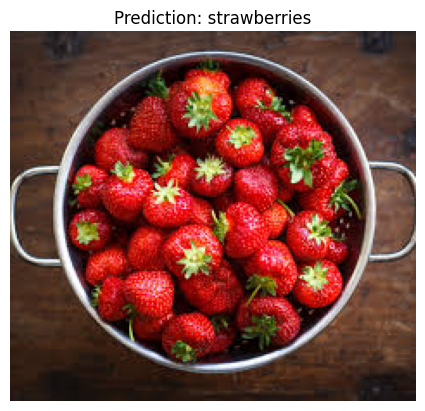

f0.jpeg → strawberries


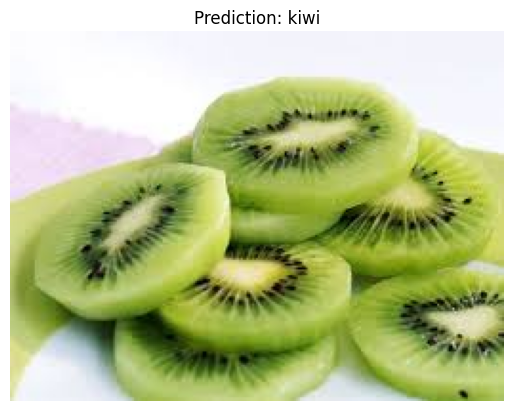

147.jpeg → kiwi


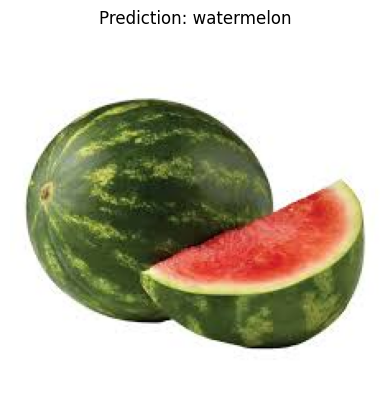

023.jpeg → watermelon


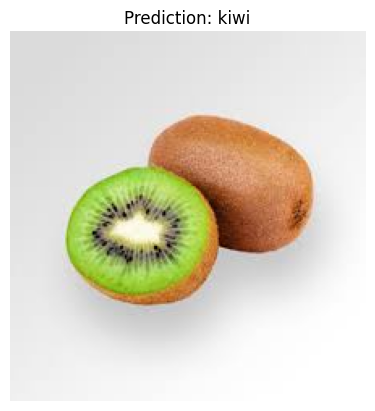

202.jpeg → kiwi


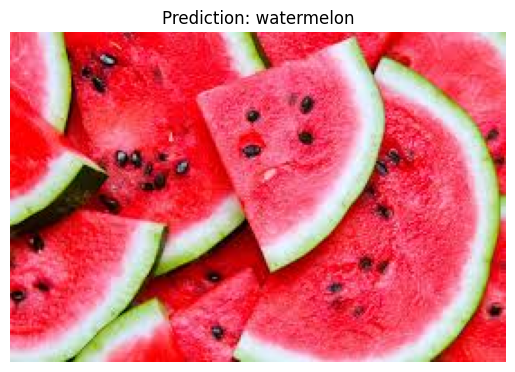

011.jpeg → watermelon


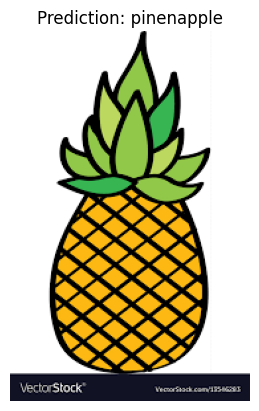

33.jpeg → pinenapple


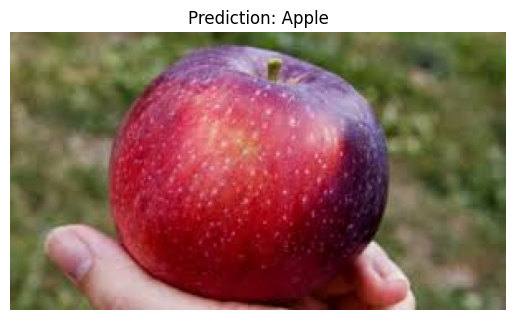

3.jpeg → Apple


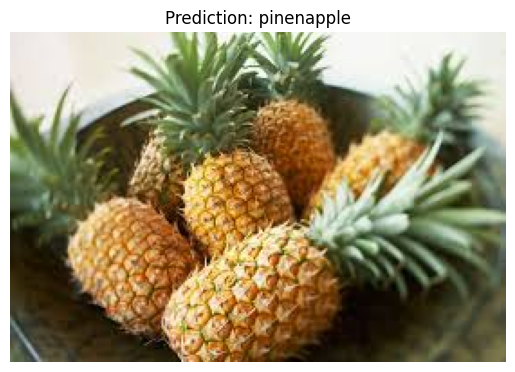

77.jpeg → pinenapple


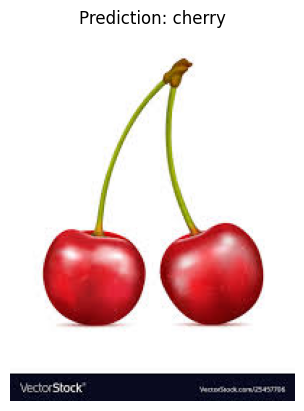

68.jpeg → cherry


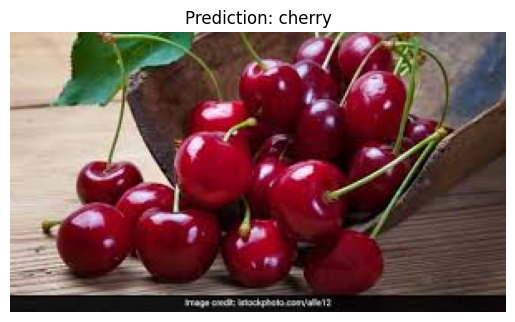

65.jpeg → cherry


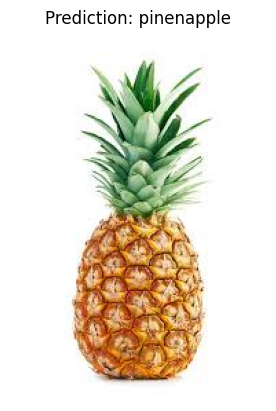

22.jpeg → pinenapple


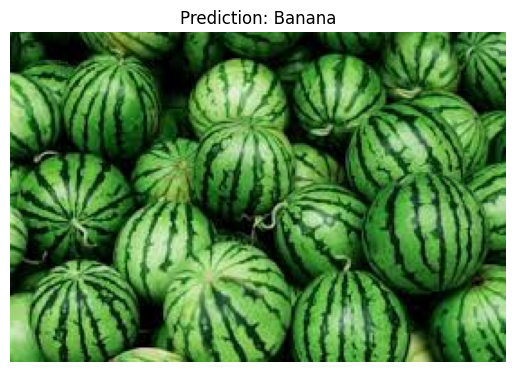

0122.jpeg → Banana


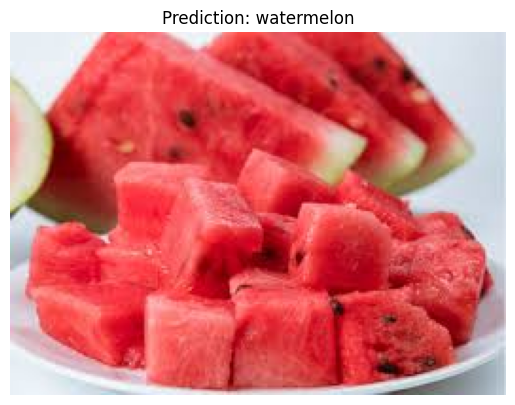

012.jpeg → watermelon


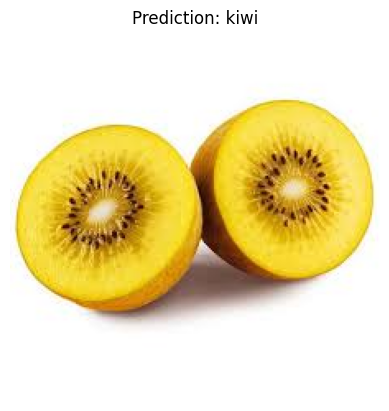

659.jpeg → kiwi


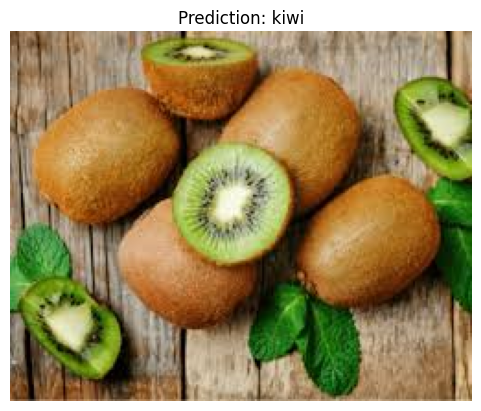

321.jpeg → kiwi


In [ ]:
import matplotlib.pyplot as plt

model.eval()

for img_name in os.listdir(pred_path)[:15]:
    img_path = os.path.join(pred_path, img_name)

    img = Image.open(img_path).convert("RGB")

    img_tensor = test_transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = model(img_tensor)
        _, pred = torch.max(output, 1)

    label = classes[pred.item()]

    plt.imshow(img)
    plt.title(f"Prediction: {label}")
    plt.axis("off")
    plt.show()

    print(img_name, "→", label)